<a href="https://colab.research.google.com/github/devopsalok/salesPrediction/blob/Master/Sales_chart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can access datasets from Git repositories by cloning the repository to your environment and then reading the file from the local copy. Here's how you can do it in Colab:

In [8]:
# Clone the repository
!git clone https://github.com/devopsalok/salesPrediction.git

# Change directory to the cloned repository (replace <repository_name>)
# %cd <repository_name>

# Read the dataset using pandas (replace <dataset_path>)

# df.dropna(inplace=True) # This line will be moved to a new cell
# Display the first few rows of the dataframe
# display(df.head()) # This line will be moved to a new cell

fatal: destination path 'salesPrediction' already exists and is not an empty directory.


In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
df = pd.read_csv('/content/salesPrediction/sales data file.csv')
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [14]:
df.dropna(inplace=True)
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


array([[<Axes: title={'center': 'TV'}>,
        <Axes: title={'center': 'Radio'}>],
       [<Axes: title={'center': 'Newspaper'}>,
        <Axes: title={'center': 'Sales'}>]], dtype=object)

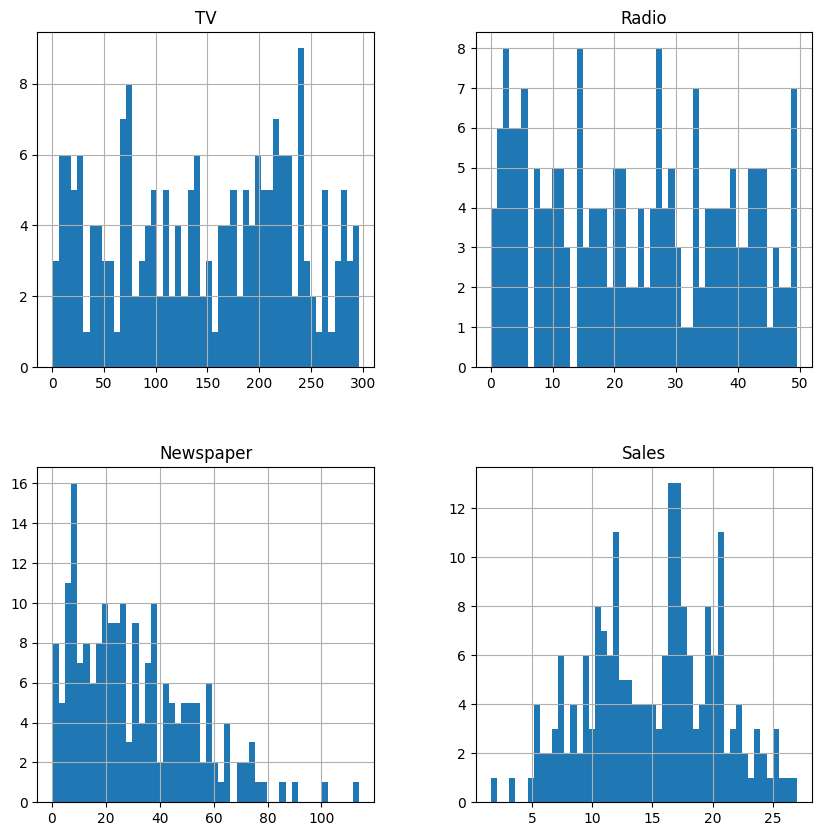

In [17]:
df.hist(figsize=(10,10), bins =50 )

<Axes: >

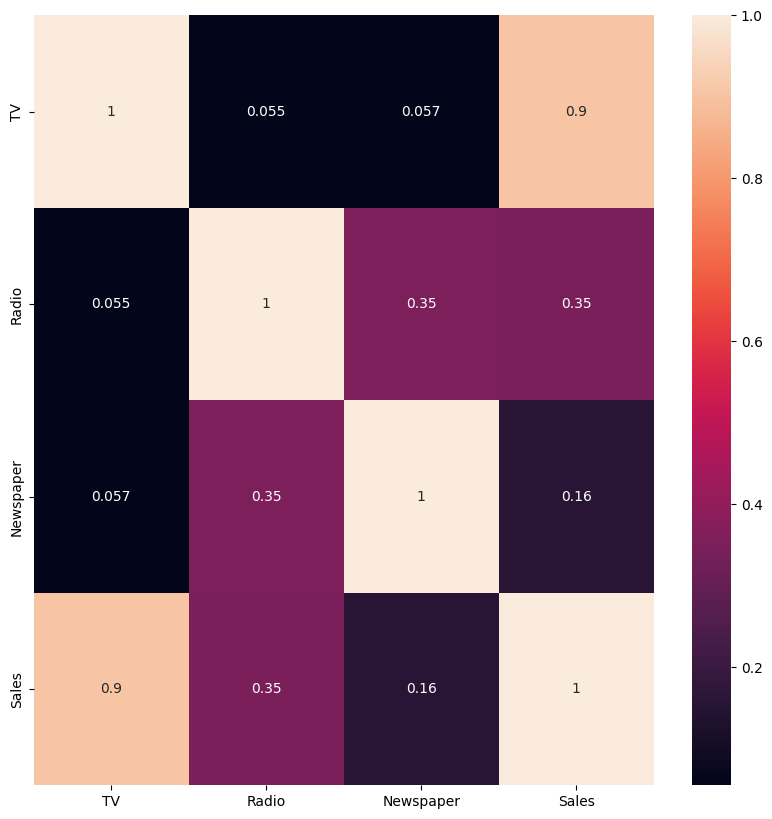

In [18]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True)

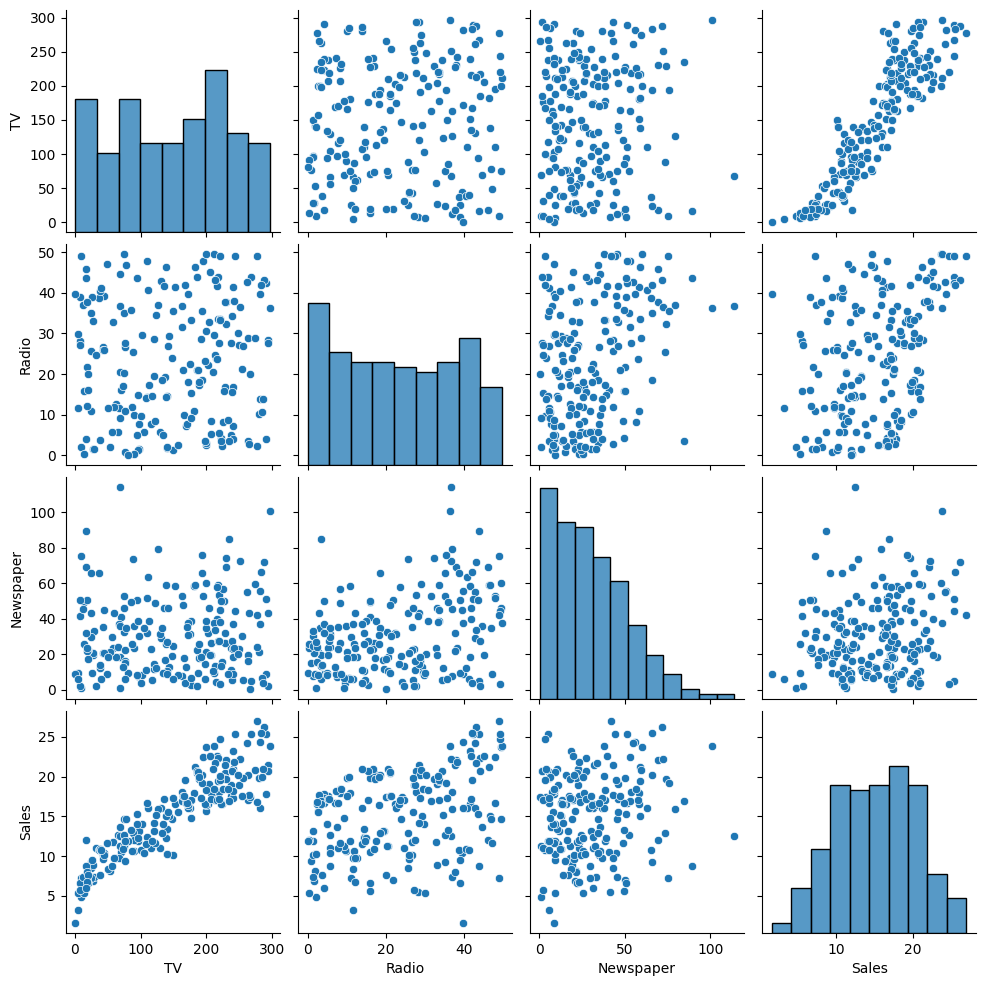

In [19]:
sns.pairplot(df)
plt.show()

In [20]:
X = df.drop('Sales', axis=1)
X

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [21]:
y = df["Sales"]
y = pd.DataFrame(y)
y

,Sales
0,22.1
1,10.4
2,12.0
3,16.5
4,17.9
...,...
195,7.6
196,14.0
197,14.8
198,25.5


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

regression_Model = RandomForestRegressor(n_estimators=250,random_state=0)
regression_Model.fit(X_train, y_train)

y_pred = regression_Model.predict(X_test)
y_pred

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


array([17.4584, 22.466 , 19.9276,  6.5236, 23.036 , 13.6604, 22.7572,
        9.4376, 16.918 , 16.8516,  7.5012, 10.3704, 17.2548,  4.4324,
       11.7168, 16.9144,  6.212 , 17.524 , 11.6364, 19.7992, 19.7112,
       13.3432, 10.0996, 21.9692, 11.222 , 10.0428, 22.8088, 12.4672,
       11.5972,  5.2124, 16.5824, 11.3504, 23.0116, 10.1336, 19.9596,
       20.0996, 11.1796, 19.5704, 12.3428,  7.4552])

In [26]:
print('Random Forest Regressor Train Score is : ' ,  regression_Model.score(X_train, y_train))
print('Random Forest Regressor Test Score is : ' , regression_Model.score(X_test, y_test))

Random Forest Regressor Train Score is :  0.9914586097497989
Random Forest Regressor Test Score is :  0.9524970507845999


In [24]:
print('Random Forest Regression Model')
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R2 Score:', r2_score(y_test, y_pred))

Random Forest Regression Model
Mean Squared Error: 1.4678933839999992
R2 Score: 0.9524970507845999


In [33]:
# =======================================
# Interactive AutoML Prediction Notebook
# =======================================

import pandas as pd
import numpy as np
import io
from IPython.display import display
import ipywidgets as widgets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score
import matplotlib.pyplot as plt

# --- Step 1: Upload widget ---
upload = widgets.FileUpload(
    accept='.csv,.xlsx,.xls,.json',
    multiple=False,
    description='📂 Upload Dataset'
)
display(upload)

# Function to read uploaded file
def load_uploaded_file(uploaded_file):
    content = list(uploaded_file.value.values())[0]
    name = content['metadata']['name']
    data = content['content']
    file = io.BytesIO(data)

    if name.endswith('.csv'):
        df = pd.read_csv(file)
    elif name.endswith(('.xls', '.xlsx')):
        df = pd.read_excel(file)
    elif name.endswith('.json'):
        df = pd.read_json(file)
    else:
        raise ValueError("Unsupported file format!")
    return df

output = widgets.Output()

def on_upload_change(change):
    with output:
        output.clear_output()
        if upload.value:
            df = load_uploaded_file(upload.value)
            print("✅ Dataset Loaded Successfully!")
            print("Shape:", df.shape)
            display(df.head())

            # Step 2: Choose target column
            target_dropdown = widgets.Dropdown(
                options=df.columns.tolist(),
                description='🎯 Target:',
                style={'description_width': 'initial'}
            )

            def on_target_select(change):
                target = target_dropdown.value
                with output:
                    output.clear_output(wait=True)
                    print(f"Selected Target: {target}")

                    # Prepare data
                    X = df.drop(columns=[target])
                    y = df[target]
                    X = pd.get_dummies(X, drop_first=True)

                    X_train, X_test, y_train, y_test = train_test_split(
                        X, y, test_size=0.2, random_state=42
                    )

                    # Determine model type
                    if y.dtypes in ['int64', 'float64']:
                        print("\n📈 Training Regression Model...")
                        model = RandomForestRegressor(random_state=42)
                        model.fit(X_train, y_train)
                        y_pred = model.predict(X_test)
                        mse = mean_squared_error(y_test, y_pred)
                        print(f"✅ Model Trained! Mean Squared Error: {mse:.4f}")

                        result_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
                        display(result_df.head(10))

                        plt.figure(figsize=(6,4))
                        plt.scatter(y_test, y_pred, alpha=0.6)
                        plt.xlabel("Actual")
                        plt.ylabel("Predicted")
                        plt.title("Actual vs Predicted")
                        plt.show()

                    else:
                        print("\n🔍 Training Classification Model...")
                        model = RandomForestClassifier(random_state=42)
                        model.fit(X_train, y_train)
                        y_pred = model.predict(X_test)
                        acc = accuracy_score(y_test, y_pred)
                        print(f"✅ Model Trained! Accuracy: {acc*100:.2f}%")

                        result_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
                        display(result_df.head(10))

                        plt.figure(figsize=(6,4))
                        plt.bar(["Correct", "Incorrect"], [
                            np.sum(y_test == y_pred),
                            np.sum(y_test != y_pred)
                        ])
                        plt.title("Prediction Results")
                        plt.show()

            display(target_dropdown)
            target_dropdown.observe(on_target_select, names='Sales')

upload.observe(on_upload_change, names='Sales')
display(output)


FileUpload(value={}, accept='.csv,.xlsx,.xls,.json', description='📂 Upload Dataset')

Output()